In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

engine = create_engine('sqlite:///data/rfm.db')

with open('sql/02_segmentation.sql', 'r') as f:
    sql = f.read()

df_seg = pd.read_sql(sql, engine)
print(df_seg)

    Segment  CustomerCount  PctCustomers  TotalRevenue  PctRevenue  \
0  Champion            956          22.7    5384277.64        64.7   
1     Loyal            932          22.1    1418758.52        17.1   
2   At-Risk            643          15.2     853480.20        10.3   
3      Lost           1532          36.3     633744.61         7.6   
4       New            156           3.7      26525.19         0.3   

   AvgOrderValue  
0        5632.09  
1        1522.27  
2        1327.34  
3         413.67  
4         170.03  


In [2]:
df_seg.to_sql('segments', engine, if_exists='replace', index=False)
print('Segments saved to SQLite ✓')

Segments saved to SQLite ✓


/var/folders/d1/6l59j_vj6m1905v93yt8t7h80000gn/T/ipykernel_2598/4262956186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='CustomerCount', data=df_seg, palette='viridis')


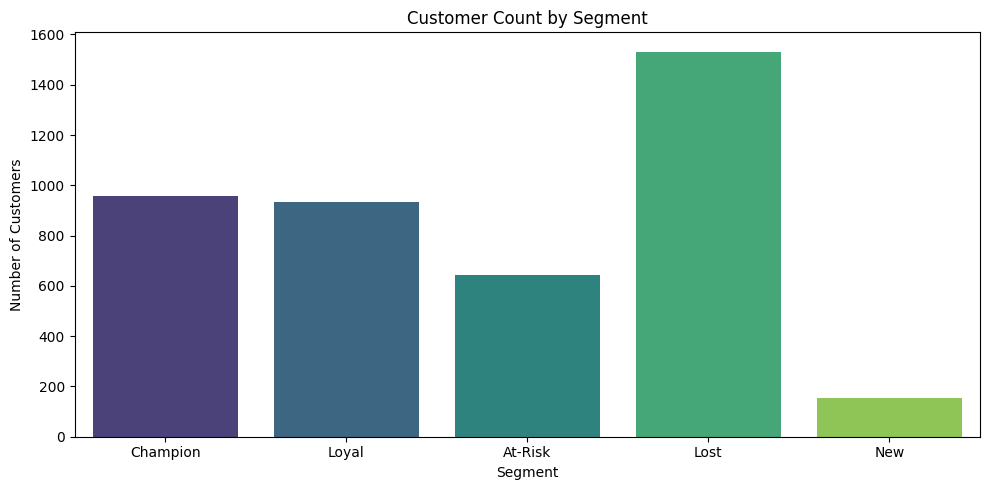

Saved ✓


In [3]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Segment', y='CustomerCount', data=df_seg, palette='viridis')
plt.title('Customer Count by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('dashboards/python/segment_distribution.png')
plt.show()
print('Saved ✓')

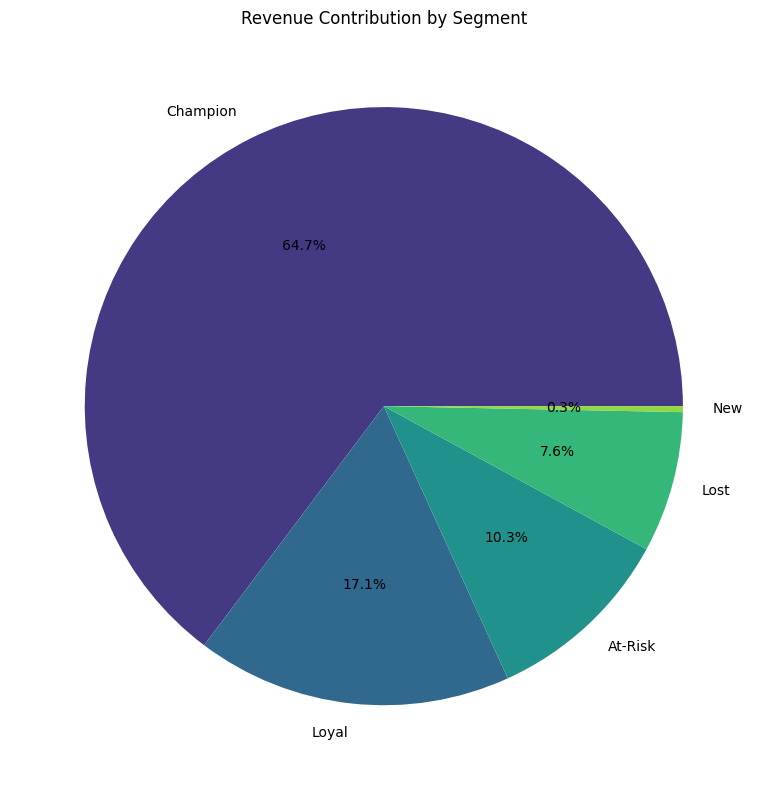

Saved ✓


In [4]:
plt.figure(figsize=(8, 8))
plt.pie(df_seg['TotalRevenue'], labels=df_seg['Segment'], 
        autopct='%1.1f%%', colors=sns.color_palette('viridis', 5))
plt.title('Revenue Contribution by Segment')
plt.tight_layout()
plt.savefig('dashboards/python/revenue_pie.png')
plt.show()
print('Saved ✓')

/var/folders/d1/6l59j_vj6m1905v93yt8t7h80000gn/T/ipykernel_2598/4208036446.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='AvgOrderValue', data=df_seg, palette='magma')


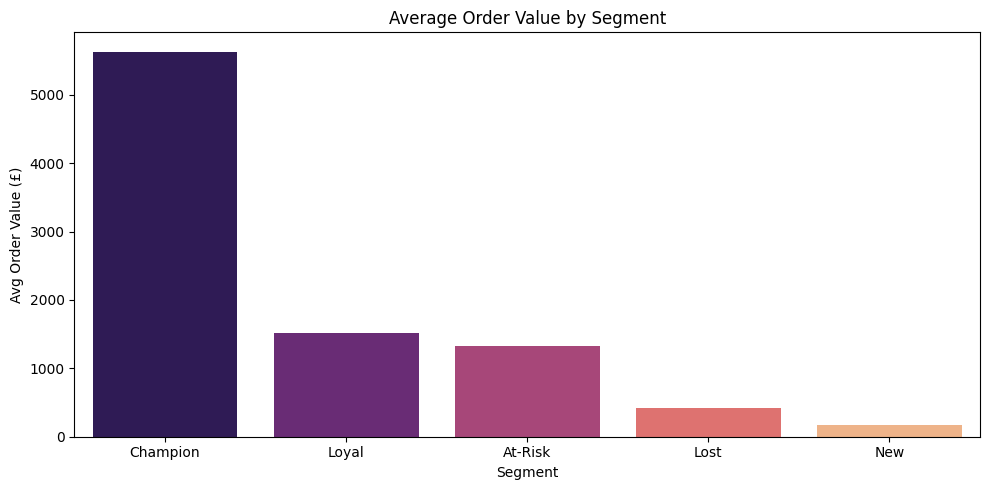

Saved ✓


In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Segment', y='AvgOrderValue', data=df_seg, palette='magma')
plt.title('Average Order Value by Segment')
plt.xlabel('Segment')
plt.ylabel('Avg Order Value (£)')
plt.tight_layout()
plt.savefig('dashboards/python/avg_order_value.png')
plt.show()
print('Saved ✓')

In [6]:
df_rfm = pd.read_sql('SELECT * FROM rfm_scores', engine)

at_risk = df_rfm[df_rfm['M'] >= 4].copy()
at_risk_pct = (at_risk['Monetary'].sum() / df_rfm['Monetary'].sum()) * 100

print(f'High-value At-Risk customers: {len(at_risk):,}')
print(f'Their revenue share: {at_risk_pct:.1f}%')

High-value At-Risk customers: 1,687
Their revenue share: 88.1%


In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///data/rfm.db')

# Export both tables to CSV
pd.read_sql('SELECT * FROM rfm_scores', engine).to_csv('data/rfm_scores.csv', index=False)
pd.read_sql('SELECT * FROM segments', engine).to_csv('data/segments.csv', index=False)

print('Exported!')

Exported!
